# Baseline Model Training and Comparison

This notebook trains and compares baseline credit scoring models before any hyperparameter tuning is considered.

## 1. Introduction

The goal of this notebook is to establish a baseline performance reference using a small set of interpretable and widely used classifiers. The results will guide future tuning and model selection decisions.

## 2. Import Libraries and Project Modules

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.train_baseline_models import load_model_ready_data, train_all_baseline_models, save_trained_models
from src.evaluation.model_comparison import compare_models, save_comparison_results, save_classification_reports, save_confusion_matrices

sns.set_theme(style="whitegrid")
print("Project root added to path:", PROJECT_ROOT)

Project root added to path: d:\CodeAlpha_Intern\CodeAlpha_CreditScoringModel


## 3. Load Model-Ready Data

In [2]:
X_train, X_test, y_train, y_test = load_model_ready_data()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts().sort_index())
print("y_test distribution:")
print(y_test.value_counts().sort_index())

X_train shape: (800, 25)
X_test shape: (200, 25)
y_train distribution:
credit_risk
0    240
1    560
Name: count, dtype: int64
y_test distribution:
credit_risk
0     60
1    140
Name: count, dtype: int64


## 4. Define Baseline Models

In [3]:
from src.models.model_registry import get_baseline_models

baseline_models = get_baseline_models()
print("Baseline models:")
for name in baseline_models:
    print(f"- {name}")

Baseline models:
- logistic_regression
- decision_tree
- random_forest
- svm
- knn


## 5. Train Baseline Models

In [4]:
trained_models = train_all_baseline_models(X_train, y_train)
saved_paths = save_trained_models(trained_models)
print("Training completed for:")
for name, path in saved_paths.items():
    print(f"- {name}: {path}")

d:\CodeAlpha_Intern\CodeAlpha_CreditScoringModel\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training completed for:
- logistic_regression: D:\CodeAlpha_Intern\CodeAlpha_CreditScoringModel\models\baseline\logistic_regression_baseline.joblib
- decision_tree: D:\CodeAlpha_Intern\CodeAlpha_CreditScoringModel\models\baseline\decision_tree_baseline.joblib
- random_forest: D:\CodeAlpha_Intern\CodeAlpha_CreditScoringModel\models\baseline\random_forest_baseline.joblib
- svm: D:\CodeAlpha_Intern\CodeAlpha_CreditScoringModel\models\baseline\svm_baseline.joblib
- knn: D:\CodeAlpha_Intern\CodeAlpha_CreditScoringModel\models\baseline\knn_baseline.joblib


## 6. Evaluate Models

In [5]:
results_df = compare_models(trained_models, X_test, y_test)
results_df

,accuracy,precision_bad,recall_bad,f1_bad,precision_good,recall_good,f1_good,macro_precision,macro_recall,macro_f1,weighted_f1,roc_auc,model_name
0,0.755,0.582090,0.650000,0.614173,0.842105,0.800000,0.820513,0.712097,0.725000,0.717343,0.758611,0.790655,random_forest
1,0.730,0.534091,0.783333,0.635135,0.883929,0.707143,0.785714,0.709010,0.745238,0.710425,0.740541,0.793333,svm
2,0.720,0.534483,0.516667,0.525424,0.795775,0.807143,0.801418,0.665129,0.661905,0.663421,0.718620,0.661905,decision_tree
3,0.680,0.476744,0.683333,0.561644,0.833333,0.678571,0.748031,0.655039,0.680952,0.654838,0.692115,0.756548,logistic_regression
4,0.710,0.520000,0.433333,0.472727,0.773333,0.828571,0.800000,0.646667,0.630952,0.636364,0.701818,0.757321,knn


## 7. Visualize Model Comparison

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_8428\3965619544.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="model_name", y="macro_f1", palette="viridis")


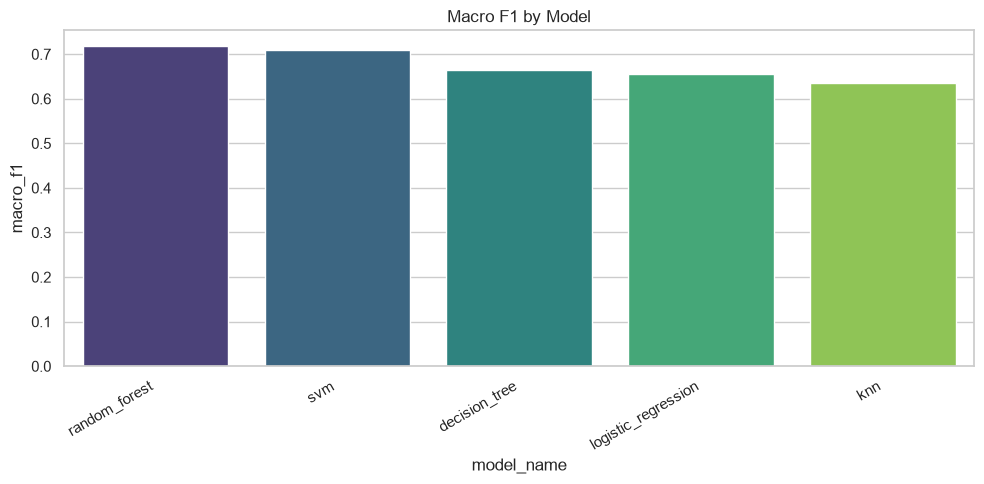

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_8428\3965619544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="model_name", y="recall_bad", palette="rocket")


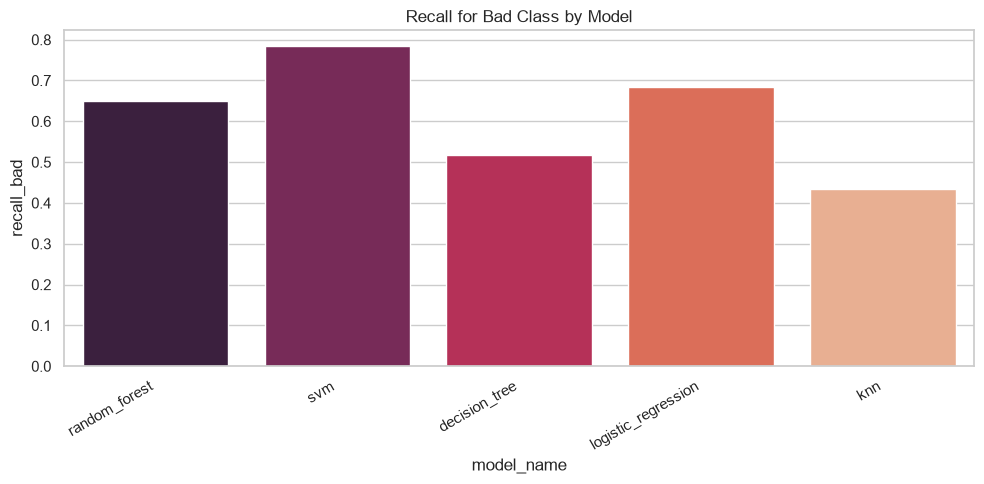

C:\Users\Muzammil\AppData\Local\Temp\ipykernel_8428\3965619544.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="model_name", y="roc_auc", palette="magma")


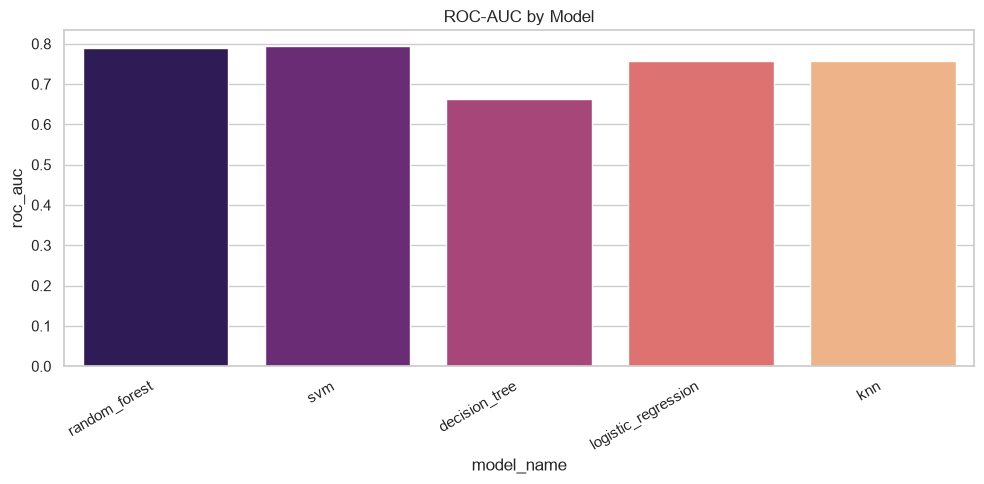

In [6]:
output_dir = PROJECT_ROOT / "images" / "model_comparison"
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="model_name", y="macro_f1", palette="viridis")
plt.title("Macro F1 by Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "macro_f1_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="model_name", y="recall_bad", palette="rocket")
plt.title("Recall for Bad Class by Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "recall_bad_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="model_name", y="roc_auc", palette="magma")
plt.title("ROC-AUC by Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "roc_auc_by_model.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Confusion Matrices

logistic_regression confusion matrix
    0   1
0  41  19
1  45  95


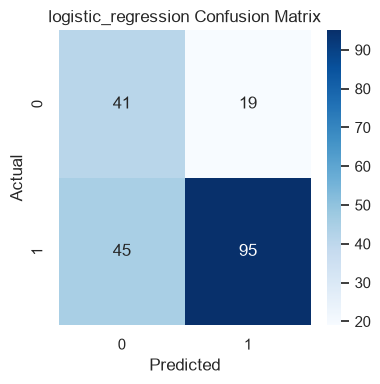

decision_tree confusion matrix
    0    1
0  31   29
1  27  113


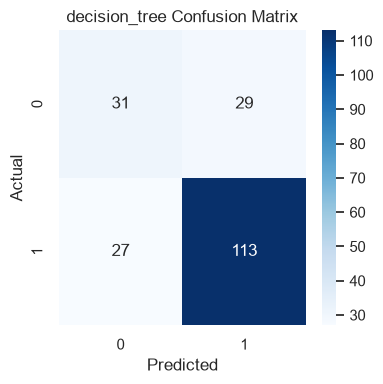

random_forest confusion matrix
    0    1
0  39   21
1  28  112


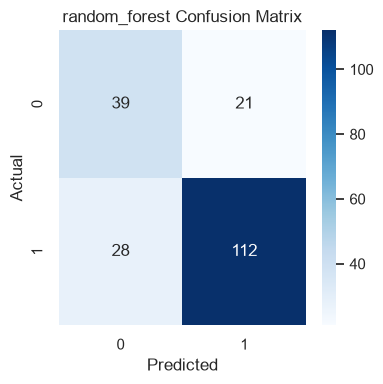

svm confusion matrix
    0   1
0  47  13
1  41  99


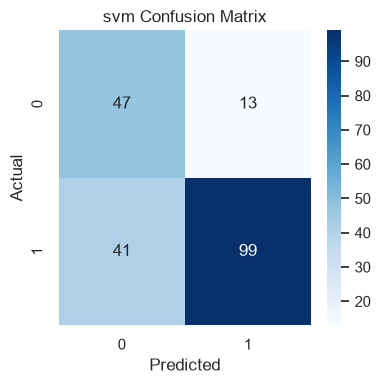

knn confusion matrix
    0    1
0  26   34
1  24  116


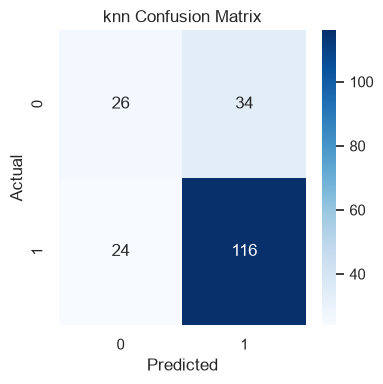

In [7]:
from src.evaluation.evaluation_metrics import get_confusion_matrix

cm_dir = output_dir / "confusion_matrices"
cm_dir.mkdir(parents=True, exist_ok=True)

for model_name, model in trained_models.items():
    cm_df = get_confusion_matrix(model, X_test, y_test)
    print(f"{model_name} confusion matrix")
    print(cm_df)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(cm_dir / f"{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

## 9. Key Findings

In [8]:
print(results_df[["model_name", "accuracy", "macro_f1", "recall_bad", "roc_auc"]].to_string(index=False))

best_model = results_df.iloc[0]["model_name"]
print(f"\nBest baseline model based on macro F1: {best_model}")

         model_name  accuracy  macro_f1  recall_bad  roc_auc
      random_forest     0.755  0.717343    0.650000 0.790655
                svm     0.730  0.710425    0.783333 0.793333
      decision_tree     0.720  0.663421    0.516667 0.661905
logistic_regression     0.680  0.654838    0.683333 0.756548
                knn     0.710  0.636364    0.433333 0.757321

Best baseline model based on macro F1: random_forest


## 10. Next Steps

The next stage should focus on hyperparameter tuning, threshold adjustment, feature importance analysis, and final model selection based on the baseline results.